In [1]:
import pandas as pd

In [2]:
data=pd.read_table('energy.dat',delimiter=' ',header=None)
data2=pd.read_table('energy2.dat',delimiter=' ',header=None)


In [3]:
data.head(5)

,0,1,2,3
0,0.000022,-0.000022,-1.0115,-1.0115
1,0.000022,-0.000022,-1.0113,-1.0113
2,0.000022,-0.000023,-1.0111,-1.0111
3,0.000022,-0.000023,-1.0109,-1.0109
4,0.000022,-0.000023,-1.0107,-1.0107


In [4]:
data2.head(5)

,0,1,2,3
0,0.000018,-0.000018,-1.0154,-1.0154
1,0.000018,-0.000018,-1.0152,-1.0152
2,0.000018,-0.000019,-1.0150,-1.0150
3,0.000018,-0.000019,-1.0148,-1.0148
4,0.000018,-0.000019,-1.0146,-1.0146


In [5]:
import matplotlib.pyplot as plt


In [6]:
data.columns=['phi','fe','dfe','chem_pot']
data2.columns=['phi','fe','dfe','chem_pot']

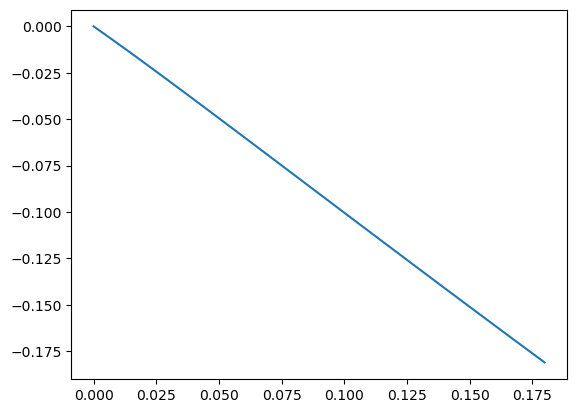

In [7]:
plt.plot(data['phi'],data['fe'])

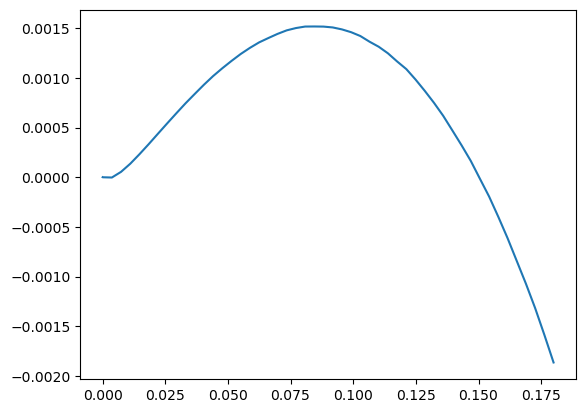

In [8]:
def fun_trans(data):
    return data['fe']-data['phi']*data['dfe']

plt.plot(data['phi'],fun_trans(data))

<Axes: xlabel='phi'>

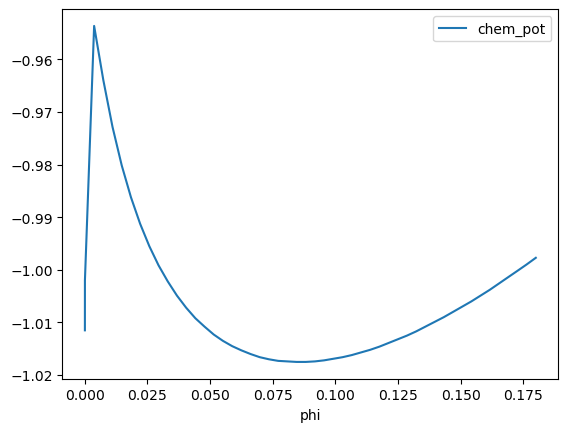

In [9]:
data.plot(x='phi',y='chem_pot')

<Axes: xlabel='phi'>

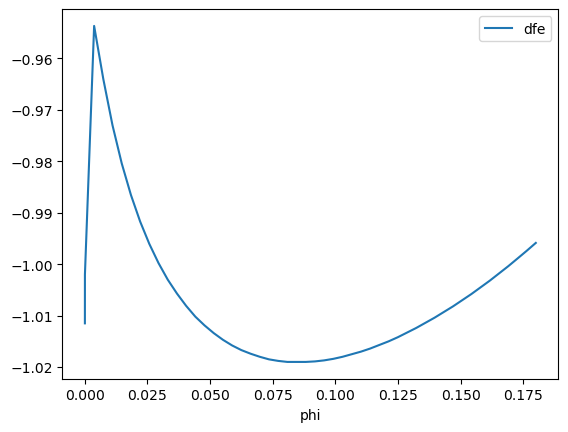

In [10]:
data.plot(x='phi',y='dfe')

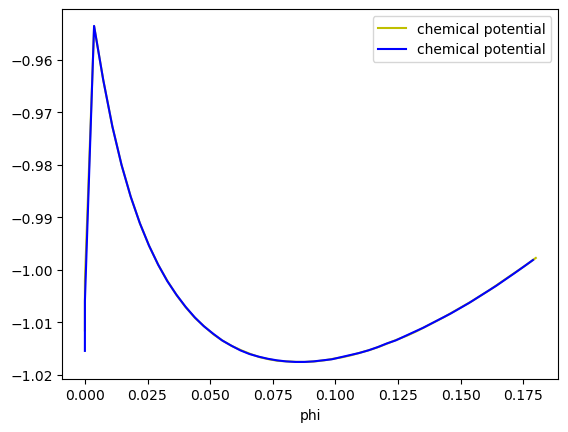

In [11]:
#plt.plot(data['phi'],data['dfe'],color='r',label='df/dphi')
plt.plot(data['phi'],data['chem_pot'],label='chemical potential',color='y')
plt.plot(data2['phi'],data2['chem_pot'],label='chemical potential',color='b')

plt.xlabel('phi')
plt.legend()


In [12]:
import numpy as np
a=np.array([1,2,3])
b=np.array([5,6])
np.concatenate((a,b))

array([1, 2, 3, 5, 6])

In [13]:
step=200

In [14]:
print(str(int(102/100)))


1


data=pd.read_table('./results/bi_RPAFH_N241_phis_0.00000_Ddx4_N1_eh0.00_es0.00_umax4.00_du0.10_ddu0.01.txt',delimiter=' ')

data.columns=['a','b']

data['c']=1/data['b']

data.plot(x='a',y='c')

In [15]:
import fipy as fp


nx=10
ny=10
phi_value=np.array( [[0.]*ny]*nx )

phi_value[0,0:10]=1

dx=1


mesh = fp.Grid2D(nx=nx, ny=ny, dx=dx, dy=dx)

In [16]:
phi_value=np.array( [[0.]*ny]*nx )
    # initial phi profile

print("haha",nx,ny,phi_value.shape)
for i in range(nx):
    for j in range(ny):
        if (j<=3):
            phi_value[i,j]=0.15
        else:
            phi_value[i,j]=0

haha 10 10 (10, 10)


In [17]:
phi_value.flatten().reshape(nx,ny)

array([[0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.15, 0.15, 0.15, 0.15, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]])

In [18]:
phi=fp.CellVariable(mesh=mesh, name=r'$\phi_{monomer}$', hasOld=True)


In [19]:
phi.setValue(phi_value.flatten())

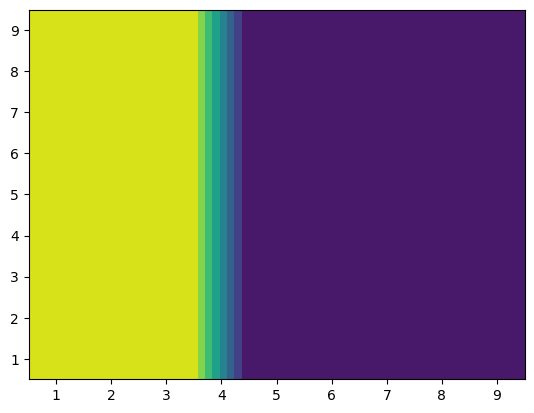

In [20]:
import matplotlib.pyplot as plt

fig, ax  =plt.subplots()
cs = ax.tricontourf(mesh.x.value,mesh.y.value,phi.value)

fig.savefig(fname='phi_image_initial.png'.format(step=0),dpi=300,format='png')

In [21]:
mesh.x.value

array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 0.5, 1.5, 2.5,
       3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5,
       6.5, 7.5, 8.5, 9.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5,
       9.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 0.5, 1.5,
       2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 0.5, 1.5, 2.5, 3.5, 4.5,
       5.5, 6.5, 7.5, 8.5, 9.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,
       8.5, 9.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 0.5,
       1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5])

In [22]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.cm as cm

delta = 0.025
x = np.arange(-3.0, 3.0, delta)
y = np.arange(-2.0, 2.0, delta)
X, Y = np.meshgrid(x, y)
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X - 1)**2 - (Y - 1)**2)
Z = (Z1 - Z2) * 2

In [23]:
mesh.x.value.reshape(5,10)

ValueError: cannot reshape array of size 100 into shape (5,10)

In [ ]:
X

In [ ]:
Y

In [ ]:

mesh2 = fp.Grid2D(nx=240, ny=160, dx=dx, dy=dx)

In [ ]:
X.shape,Y.shape,Z.shape

In [ ]:
phi.value.reshape(nx,ny).shape

In [ ]:
t=100.2

In [ ]:

fig, ax  =plt.subplots()
plt.title(str(t))
ax.legend(title=str(t))

